# Cropping a plot with `crop_coord`

Most spatial datasets are far larger than the region you want to look at. `crop_coord` restricts a
plot to a bounding box **at draw time**: the `SpatialData` object is untouched, only the window is
rendered — and for images and labels only the window is ever rasterized, so zooming into a
gigapixel slide costs about as much as plotting a thumbnail.

This tutorial uses the built-in `blobs` dataset so it runs in seconds. The same calls work on Visium,
Xenium, MERFISH, or any other `SpatialData` object.

## Setup

In [1]:
import warnings

import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

import spatialdata as sd
import spatialdata_plot  # noqa: F401  # registers the .pl accessor

warnings.filterwarnings("ignore")

sdata = sd.datasets.blobs()
sdata

SpatialData object
├── Images
│     ├── 'blobs_image': DataArray[cyx] (3, 512, 512)
│     └── 'blobs_multiscale_image': DataTree[cyx] (3, 512, 512), (3, 256, 256), (3, 128, 128)
├── Labels
│     ├── 'blobs_labels': DataArray[yx] (512, 512)
│     └── 'blobs_multiscale_labels': DataTree[yx] (512, 512), (256, 256), (128, 128)
├── Points
│     └── 'blobs_points': DataFrame with shape: (<Delayed>, 4) (2D points)
├── Shapes
│     ├── 'blobs_circles': GeoDataFrame shape: (5, 2) (2D shapes)
│     ├── 'blobs_multipolygons': GeoDataFrame shape: (2, 1) (2D shapes)
│     └── 'blobs_polygons': GeoDataFrame shape: (5, 1) (2D shapes)
└── Tables
      └── 'table': AnnData (26, 3)
with coordinate systems:
    ▸ 'global', with elements:
        blobs_image (Images), blobs_multiscale_image (Images), blobs_labels (Labels), blobs_multiscale_labels (Labels), blobs_points (Points), blobs_circles (Shapes), blobs_multipolygons (Shapes), blobs_polygons (Shapes)

## 1. Zooming in — `crop_coord`

`crop_coord` is a tuple `(xmin, xmax, ymin, ymax)` in the units of the rendered coordinate system —
the same order as `ax.axis(...)` and as `crop_coord` in `scanpy.pl.spatial` /
`squidpy.pl.spatial_scatter`. The `blobs` image is 512 × 512 pixels; we zoom into a 250 × 250 window.

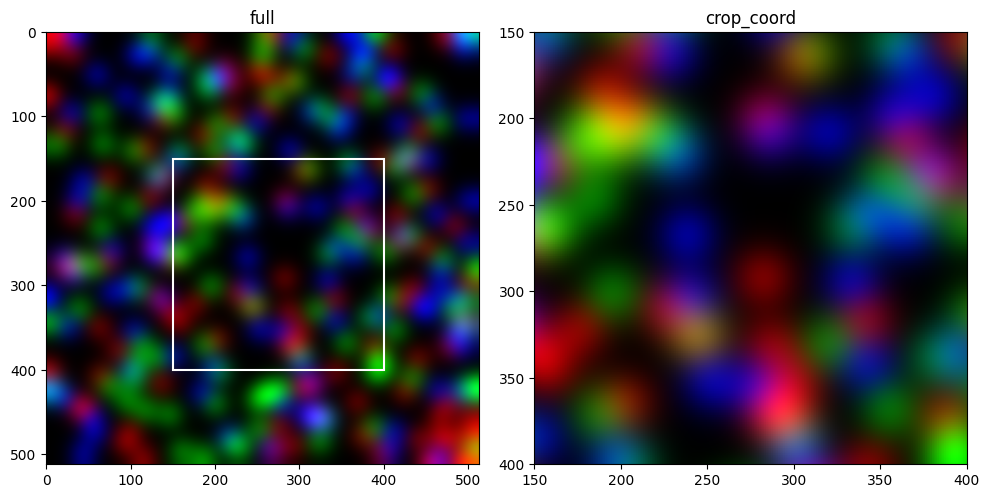

In [2]:
CROP = (150, 400, 150, 400)  # xmin, xmax, ymin, ymax

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
sdata.pl.render_images("blobs_image").pl.show(ax=axes[0], title="full")
axes[0].add_patch(
    Rectangle((CROP[0], CROP[2]), CROP[1] - CROP[0], CROP[3] - CROP[2], fill=False, edgecolor="white", lw=1.5)
)
sdata.pl.render_images("blobs_image").pl.show(ax=axes[1], crop_coord=CROP, title="crop_coord")
fig.tight_layout()

## 2. One window for every layer

`crop_coord` is a `show()` argument, so it applies to every `render_*` call in the chain. Points and
shapes are subsetted to the window before drawing; images and labels are rasterized for the window only.

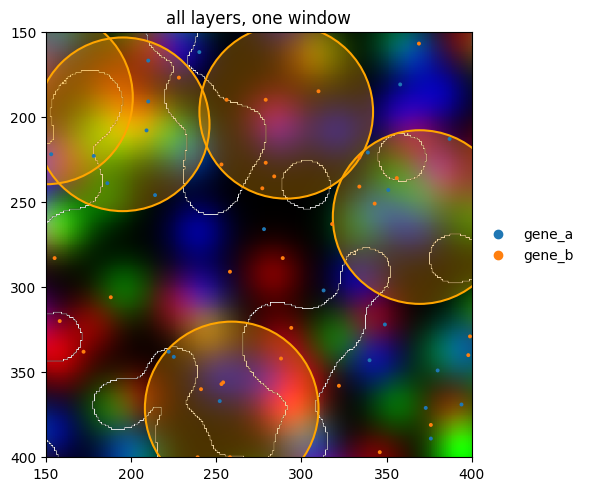

In [3]:
(
    sdata.pl.render_images("blobs_image")
    .pl.render_labels("blobs_labels", fill_alpha=0, outline_alpha=1, outline_color="white")
    .pl.render_shapes("blobs_circles", color="orange", fill_alpha=0.3, outline=True, outline_color="orange")
    .pl.render_points("blobs_points", color="genes", size=8)
    .pl.show(crop_coord=CROP, title="all layers, one window")
)

## 3. Keeping colours comparable

Cropping changes what the auto-scaled colour ranges see:

- **Points and shapes** keep the range of the *full* element, so a colour in the crop means the same
  thing as in the uncropped plot.
- **Images** are contrast-stretched over the *window*, because only the window is ever read. A crop
  of a dim region therefore looks brighter than the same region in the full plot.

To pin image contrast to the full-image range, pass explicit limits — a `norm` (or `vmin`/`vmax`):

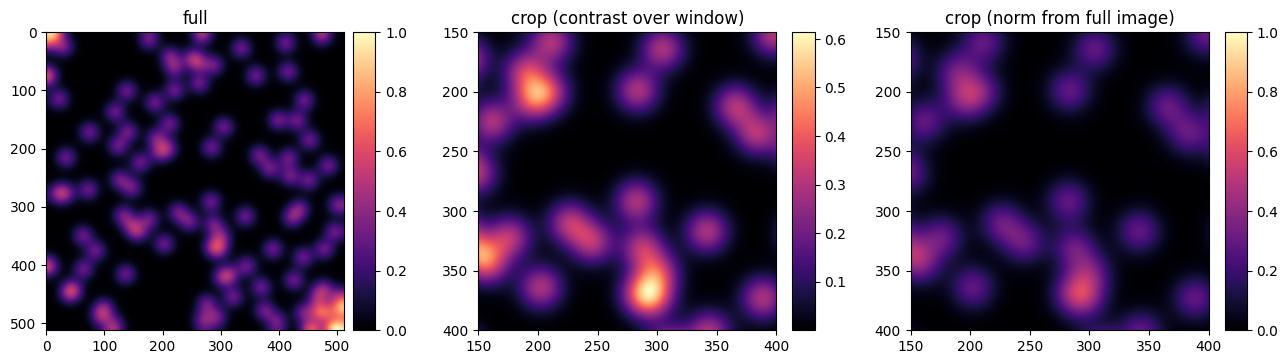

In [4]:
from matplotlib.colors import Normalize

full = sdata["blobs_image"].sel(c=0)
fixed = Normalize(vmin=float(full.min()), vmax=float(full.max()))

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
sdata.pl.render_images("blobs_image", channel=0, cmap="magma").pl.show(ax=axes[0], title="full")
sdata.pl.render_images("blobs_image", channel=0, cmap="magma").pl.show(
    ax=axes[1], crop_coord=CROP, title="crop (contrast over window)"
)
sdata.pl.render_images("blobs_image", channel=0, cmap="magma", norm=fixed).pl.show(
    ax=axes[2], crop_coord=CROP, title="crop (norm from full image)"
)
fig.subplots_adjust(wspace=0.45)

## 4. `crop_coord` vs `bounding_box_query`

`spatialdata.bounding_box_query` builds a *new* `SpatialData` object containing only the elements
inside the box. `crop_coord` changes only what is drawn. The pictures are the same; the difference is
what you are left with:

- use **`crop_coord`** to *look* at a region — nothing is copied, and images stay lazy;
- use **`bounding_box_query`** when you need the subset as data — to count, analyse, or save it.

Note the axes: the query result spans only the surviving points, while `crop_coord` pins the view to
the box.

points in full object: 200, in the query result: 53


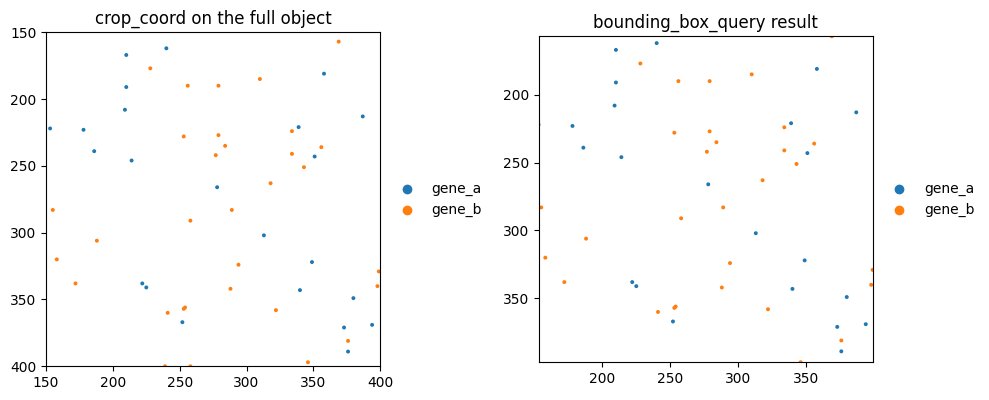

In [5]:
subset = sd.bounding_box_query(
    sdata,
    axes=("x", "y"),
    min_coordinate=[CROP[0], CROP[2]],
    max_coordinate=[CROP[1], CROP[3]],
    target_coordinate_system="global",
)
print(f"points in full object: {len(sdata['blobs_points'])}, in the query result: {len(subset['blobs_points'])}")

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
sdata.pl.render_points("blobs_points", color="genes", size=8).pl.show(
    ax=axes[0], crop_coord=CROP, title="crop_coord on the full object"
)
subset.pl.render_points("blobs_points", color="genes", size=8).pl.show(ax=axes[1], title="bounding_box_query result")
fig.tight_layout()

## 5. One coordinate system at a time

The box is expressed in one coordinate system's units, so `crop_coord` requires a single coordinate
system to be rendered. If your object has several, pick one with `coordinate_systems="global"` (or
whichever applies) in the same `show()` call.

## For reproducibility

In [6]:
# ruff: noqa: F401, F811, I001, E402
# fmt: off
import spatialdata_plot

%load_ext watermark
# fmt: on

%watermark -v -m -p spatialdata,spatialdata_plot,matplotlib,numpy

Python implementation: CPython
Python version       : 3.14.4
IPython version      : 9.13.0

spatialdata     : 0.7.3
spatialdata_plot: 0.4.2.dev11+g1d833abbf.d20260826
matplotlib      : 3.10.9
numpy           : 2.4.4

Compiler    : Clang 20.1.8 
OS          : Darwin
Release     : 25.2.0
Machine     : arm64
Processor   : arm
CPU cores   : 8
Architecture: 64bit

